#Agrupamento baseado em densidade - DBSCAN

Fonte da aula de hoje:
1. Capítulo 15 do *Livro Data Mining and Machine Learning: Fundamental Concepts and Algorithms* (https://dataminingbook.info/book_html/) - Inclusive, várias figuras!

## O Problema de agrupamento

Dada uma coleção de objetos $X = \{x_1, x_2, \dots, x_n\}$, o objetivo é dividir os elementos de $X$ em grupos de forma que:
1. Elementos do mesmo grupo **sejam** "similares"
2. Elementos de grupos diferentes **não sejam** "similares"

Dentro de aprendizado de máquina, o problema de agrupamento está na categoria de **aprendizado não supervisionado**. Essa denominação é dada pois o objetivo é aprender a partir de dados não rotulados.

## Grupos formados por densidade

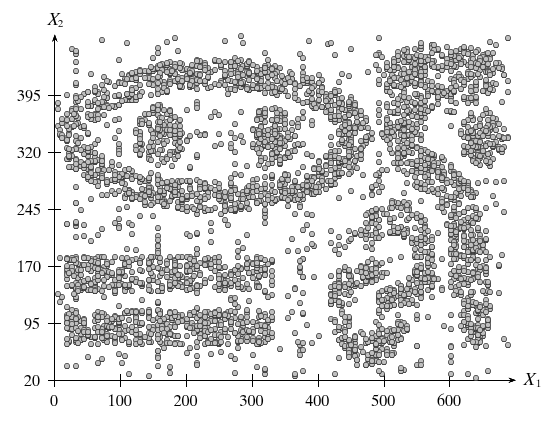

Na figura acima, pode-se perceber que há grupos naturais com diferentes formas e características. Quais são eles?

No entanto, uma coisa, aparentemente, em comum é que todos são aglomerados de pontos com uma mesma "densidade" (concentração de pontos por unidade de área).

Para situações como essa, um algoritmo de agrupamento simples e popular é o DBSCAN (*Density-Based Spatial Clustering of Applications with Noise*)

Interessantemente, como o próprio nome do algoritmo sugere, além de agrupamento, o algoritmo também é capaz de identificar e separar o "ruído" do conjunto de dados.

Antes de começar, precisamos de **várias** definições...

## Parte I - Definições

Para todas as definições abaixo, considere $X = \{x_1, x_2, \dots, x_n\}$, com $x_i \in \mathbb{R}^d$.

### $\epsilon$-vizinhança



Dado um $\mathbf{x} \in \mathbb{R}^d$, a $\epsilon$-vizinhança de $\mathbf{x}$ é dada por:
$$N_\epsilon(\mathbf{x}) = \{\mathbf{y} \in X : \Vert\mathbf{x}- \mathbf{y}\Vert_2 \le \epsilon\}.$$

Aqui, $\Vert\mathbf{x}- \mathbf{y}\Vert_2$ representa a distância euclidiana entre $\mathbf{x}$ e $\mathbf{y}$. No entanto, outras distâncias/métricas podem ser utilizadas.

A Figura abaixo ilustra o conceito de $N_\epsilon(\mathbf{x})$

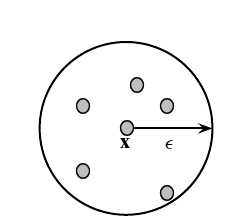

### *Core point*

Dada uma constante inteira $\eta$ (um hiperparâmetro), $\mathbf{x} \in X$ é dito ser um *core point* se $$|N_\epsilon(\mathbf{x})| \ge \eta.$$

Na Figura abaixo, se $\eta = 6$, então $\mathbf{x}$ é um *core point*.

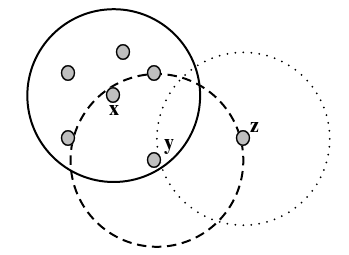

### *Border point*

$\mathbf{x} \in X$ é *border point* se $|N_\epsilon(\mathbf{x})| < \eta$, mas existe $\mathbf{y} \in X$ tal que $|N_\epsilon(\mathbf{y})| \ge \eta$ e $\mathbf{x} \in N_\epsilon(\mathbf{y})$.

Em outras palavras, $\mathbf{x}$ é *border point* se se $\mathbf{x}$ não é *core point*, mas está na $\epsilon$-vizinhança de um *core point*.

Na Figura abaixo, considerando $\eta = 6$, temos que $\mathbf{y}$ é um *border point*.

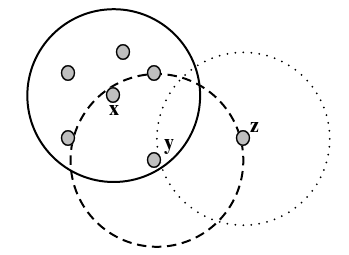

### *Noise point*

$\mathbf{x} \in X$ é *noise point* se não é *core point* nem *border point*.

Na Figura abaixo, se $\eta = 6$, então $\mathbf{z}$ é *noise point*.

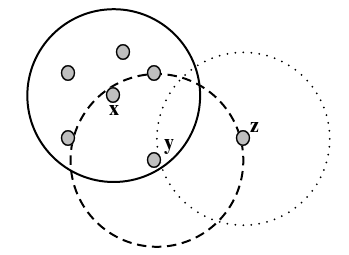

### Alcance Direto por Densidade

Um ponto $\mathbf{x} \in X$ é dito ser Diretamente Alcançável por Densidade (DDR -- *Directly Density Reachable*) de $\mathbf{y} \in X$ se
$$\mathbf{x} \in N_\epsilon(\mathbf{y})$$ e $$|N_\epsilon(\mathbf{y})| \ge \eta.$$

Ou seja, se $\mathbf{x}$ está na vizinhança de $\mathbf{y}$ e $\mathbf{y}$ é *core point*.

Nesse caso, é comum escrever $\mathbf{x}$ DDR $\mathbf{y}$.

#### Pergunta

$\mathbf{x}$ DDR $\mathbf{y}$ $\implies$ $\mathbf{y}$ DDR $\mathbf{x}$?

#### Resposta

Não! Pois, veja que $\mathbf{x}$ pode não ser um *core point*.

(veja o exemplo da Figura anterior)

### Alcance por Densidade

Um ponto $\mathbf{x} \in X$ é dito ser Alcançável por Densidade (DR -- *Density Reachable*) de $\mathbf{y} \in X$ se existe uma cadeia de pontos $x_0, x_1, \dots, x_l$, todos pertencentes a $X$ tais que:

- $x_0 = \mathbf{y},$

- $x_l = \mathbf{x}$ e

- $x_i$ DDR $x_{i - 1}$, $i = 1, \dots, l$.

Veja que $\mathbf{x}$ não precisa ser um *core point*, mas todos os outros da "cadeia" precisam.

Nesse caso, é comum escrever $\mathbf{x}$ DR $\mathbf{y}$.

Na Figura abaixo ([fonte](https://en.wikipedia.org/wiki/DBSCAN)), temos que, considerando $\eta = 4$:
- $B$ DR $A$ e
- $C$ DR $A$.

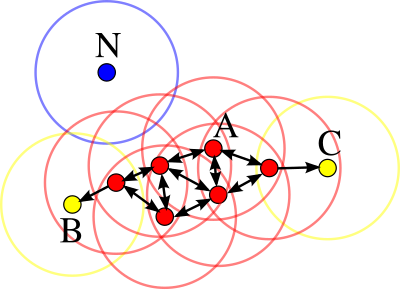

### Conexão por Densidade

$\mathbf{x} \in X$ e $\mathbf{y} \in X$ são Conectados por Densidade (DC -- *Density Connected*) se existe $\mathbf{z}\in X$ tal que:
- $\mathbf{x}$ DR $\mathbf{z}$
e
- $\mathbf{y}$ DR $\mathbf{z}$.

Nesse caso, é comum escrever $\mathbf{x}$ DC $\mathbf{y}$.

Na Figura acima, $B$ DC $C$. Uma vez que $C$ DR $A$ e $B$ DR $A$.

#### Pergunta

$\mathbf{x}$ DC $\mathbf{y}$ $\implies$ $\mathbf{y}$ DR $\mathbf{x}$ ou $\mathbf{x}$ DR $\mathbf{y}$?

#### Resposta

Não! Pois, veja que não é necessário que $\mathbf{x}$ ou $\mathbf{y}$ sejam *core points*.

(veja o exemplo da Figura anterior)

### Grupo Baseado em Densidade

$Z \subseteq X$ é dito ser um Grupo Baseado em Densidade (DBC - *Density Based Cluster*) se para todo par $\mathbf{x}$, $\mathbf{y} \in Z$, tem-se que $\mathbf{x}$ DC $\mathbf{y}$. Além disso, $Z$ deve ser *maximal* em $X$ com respeito a relação DC.

Na Figura abaixo ([fonte](https://en.wikipedia.org/wiki/DBSCAN)), tem-se que as áreas em azul e verde são Grupos Baseados em Densidade.

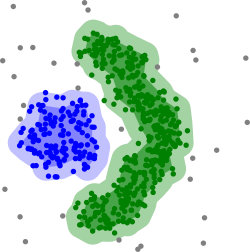

### Agrupamento baseado em densidade

Com base nas definições acima, podemos formalizar o problema de encontrar grupos baseados em densidade.

#### Entrada

- Um conjunto de pontos $X = \{x_1, \dots, x_n\}$;
- Um inteiro positivo $\eta$; e
- Um número real positivo $\epsilon$.

**Importante:** Veja que o número de grupos não faz parte da entrada. Na verdade, ele é uma consequência das escolhas de $\eta$ e $\epsilon$.


#### Saída

- Todos os Grupos Baseados em Densidade de $X$
- Os pontos que não estiverem em nenhum grupo serão considerados ruído.

## DBSCAN

Dessa forma, para resolver o problema acima, tem-se o seguinte algoritmo.

DBSCAN($X$, $\eta$, $\epsilon$):
>1. Rotule cada elemento de $X$ em *core point*, *border point* ou *noise point*
>2. Elimine os *noise points*
>3. Adicione uma conexão (aresta) entre todos os *core points* que estiverem numa distância máxima $\epsilon$ uns dos outros
>4. Cada componente conexa de *core points* é um grupo
>5. Associe cada *border point* ao grupo do *core point* mais próximo

## Na ``scikit-learn``

A biblioteca [``scikit-learn``](https://scikit-learn.org/stable/modules/generated/sklearn.cluster.DBSCAN.html) possui funcionalidades para utilizar o DBSCAN de maneira similar aos outros algoritmos de agrupamento estudados.

In [ ]:
from sklearn.datasets import make_blobs
from sklearn.preprocessing import StandardScaler

centers = [[1, 1], [-1, -1], [1, -1]]
X, labels_true = make_blobs(
    n_samples=750, centers=centers, cluster_std=0.4, random_state=0
)

X = StandardScaler().fit_transform(X)

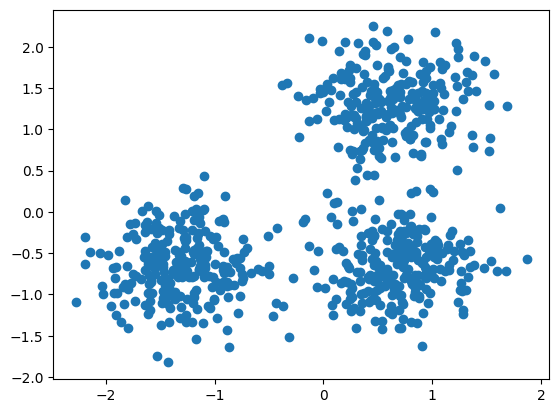

In [ ]:
#@title
import matplotlib.pyplot as plt

plt.scatter(X[:, 0], X[:, 1])
plt.show()

In [ ]:
import numpy as np

from sklearn import metrics
from sklearn.cluster import DBSCAN

# Para testes!
# 0.3, 0.4, 0.35, 0.32, 0.31
# 5, 6, 7
db = DBSCAN(eps = 0.25, min_samples = 10).fit(X)
labels = db.labels_

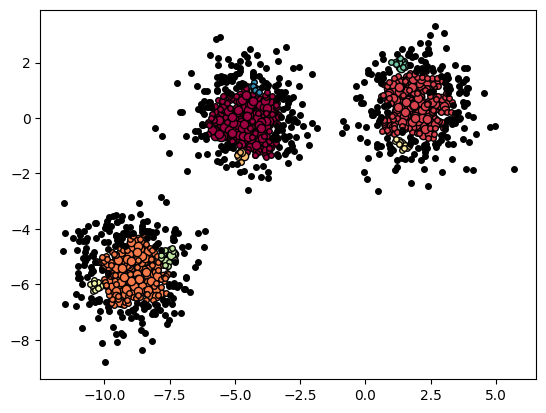

In [ ]:
#@title
unique_labels = set(labels)
core_samples_mask = np.zeros_like(labels, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True

colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]
for k, col in zip(unique_labels, colors):
    if k == -1:
        col = [0, 0, 0, 1]

    class_member_mask = labels == k

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=6,
    )

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(
        xy[:, 0],
        xy[:, 1],
        "o",
        markerfacecolor=tuple(col),
        markeredgecolor="k",
        markersize=4,
    )

## Como definir $\eta$ e $\epsilon$?

Assim como é complicado encontrar o $k$ correto do $k$-means, um desafio muito grande no DBSCAN é acertar os valores corretos de $\eta$ e $\epsilon$.

Para ver isso, a título de exemplo, varie tais hiperparâmetros no código acima.

Lembrando que, no caso geral, não podemos "ver" os grupos no plano cartesiano.

Uma heurística "razoável" é dada a seguir ([fonte](https://en.wikipedia.org/wiki/DBSCAN)):

- Para $\eta$: uma regra razoável é que $\eta \ge d + 1$, onde $d$ é o número de dimensões do conjunto de dados. Assim, sugere-se $\eta = 2d$, mas um valor maior pode ser necessário se o conjunto de dados for muito grande ou tiver muito ruído.
- Dado um $\eta$ fixo, para $\epsilon$, é comum usar o seguinte:
>- Calcule a distância de cada ponto do conjunto de dados para o $(\eta - 1)$-ésimo vizinho mais próximo.
>- Ordene os valores obtidos no passo anterior e faça um gráfico com tais valores.
>- Escolha $\epsilon$ como o valor da distância relacionada ao ponto em que a curva apresentar um "cotovelo".

In [ ]:
#@title
from sklearn.neighbors import NearestNeighbors
def find_epsilon(X, eta):
    nbrs = NearestNeighbors(n_neighbors = eta - 1, algorithm='ball_tree', metric = 'l2').fit(X)
    distances, indices = nbrs.kneighbors(X)
    y = sorted(distances.ravel())
    plt.plot(range(len(y)), y)
    plt.xlabel('Rank')
    plt.ylabel('Distância para o ' + str(eta - 1) + "-ésimo vizinho mais próximo")
    plt.show()

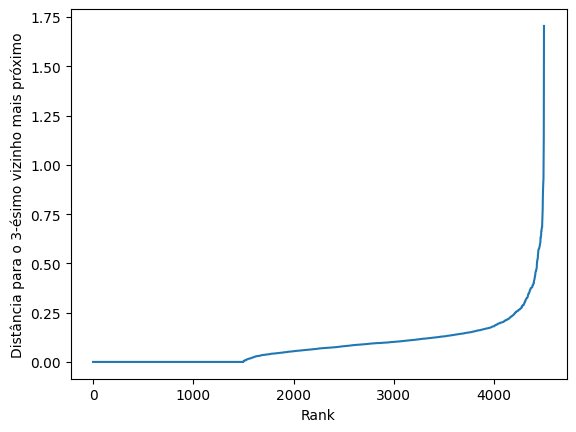

In [ ]:
find_epsilon(X, 4)

No geral, definir os valores de $\eta$ e $\epsilon$ no DBSCAN é uma tarefa complicada! O conhecimento do domínio do problema pode ajudar!

### Veja o caos!

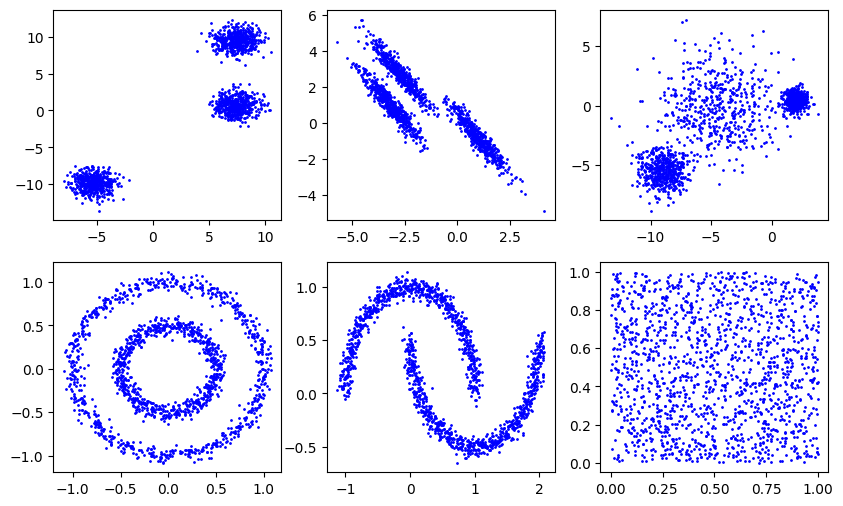

In [ ]:
#@title
import numpy as np
from sklearn import cluster, datasets
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(0)
n_samples = 1500

# circles
noisy_circles, _ = datasets.make_circles(n_samples=n_samples, factor=.5,
                                         noise=.05)

# moons
noisy_moons, _ = datasets.make_moons(n_samples=n_samples, noise=.05)

# blobs
blobs, _ = datasets.make_blobs(n_samples=n_samples, random_state=8)

# no structure
no_structure = np.random.rand(n_samples, 2)

# elipses
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = X_aniso

# blobs with varied variances
varied, _ = datasets.make_blobs(n_samples=n_samples,
                             cluster_std=[1.0, 2.5, 0.5],
                             random_state=random_state)

def plot_figure_example(color):
  f, axarr = plt.subplots(2, 3, figsize=(10, 6))
  axarr[0, 0].scatter(blobs[:, 0], blobs[:, 1], s = 1, c = color[0])
  axarr[0, 1].scatter(aniso[:, 0], aniso[:, 1], s = 1, c = color[1])
  axarr[0, 2].scatter(varied[:, 0], varied[:, 1], s = 1, c = color[2])
  axarr[1, 0].scatter(noisy_circles[:, 0], noisy_circles[:, 1], s = 1,
                      c = color[3])
  axarr[1, 1].scatter(noisy_moons[:, 0], noisy_moons[:, 1], s = 1, c = color[4])
  axarr[1, 2].scatter(no_structure[:, 0], no_structure[:, 1], s = 1,
                      c = color[5])

plot_figure_example([["blue"] for _ in range(6)])

In [ ]:
#@title
def exec_model(datasets, model, param):
  labels = []
  if model == cluster.DBSCAN:
    for idx, dataset in enumerate(datasets):
      km = model(eps = param[0], min_samples = param[1])
      km.fit(datasets[idx])
      labels.append(km.labels_)
  color = "blue red green yellow black purple brown".split()
  c = []
  for label in labels:
    c.append([color[w % len(color)] for w in label])
  return c

datasets = [blobs, aniso, varied, noisy_circles, noisy_moons, no_structure]

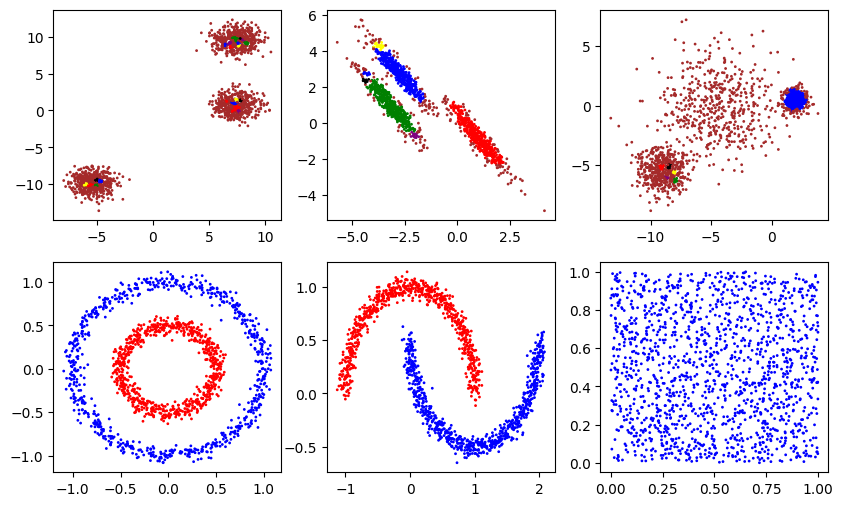

In [ ]:
colors = exec_model(datasets, cluster.DBSCAN, (0.15, 8))
plot_figure_example(colors)

Observe que quando os grupos têm densidades diferentes, o DBSCAN tem muita dificuldade em delimitar todos os grupos corretamente.

## Vantagens e Desvantagens

Em resumo, o DBSCAN tem as seguintes vantagens e desvantagens:


### Vantagens

- Não requer que o número de grupos seja informado;
- Consegue encontrar grupos com formas variadas e não convexas;
- Consegue separar "padrão" de "ruído" e "outliers" do conjunto de dados;
- Os parâmetros $\eta$ e $\epsilon$ podem ser informados por especialistas do domínio;


### Desvantagens

- Dificuldade para informar os parâmetros $\eta$ e $\epsilon$ sem um conhecimento profundo do domínio da aplicação;
- Tem muita dificuldade de encontrar grupos com densidades diferentes. Os parâmetros que podem ser adequados a um grupo podem não ser adequados aos demais.

## HDBSCAN

Para os/as interessados/as, existe uma evolução do DBSCAN, conhecida como HDBSCAN (*Hierarchical* DBSCAN). Essa versão consegue evitar algumas das desvantagens do DBSCAN. Em especial, o HDSCAN consegue identificar grupos com densidades diferentes. Exemplos [aqui](https://scikit-learn.org/stable/auto_examples/cluster/plot_hdbscan.html#sphx-glr-auto-examples-cluster-plot-hdbscan-py).